<a href="https://colab.research.google.com/github/WendyValdes/YOLO-DATASET-COCO/blob/main/YOLO%2BCOCO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

YOLO + COCO (person, car)

Installation of the premises

In [1]:
!pip install -U fiftyone ultralytics

import fiftyone as fo
import fiftyone.zoo as foz
from fiftyone import ViewField as F
from ultralytics import YOLO
import os

Upload COCO 2017 (only person and car images, maximum 500 images to reduce loading time)

In [5]:
dataset_name_train = "coco-2017-person-car-train"
# Delete the existing dataset if it already exists to force a new clean download/load.
if fo.dataset_exists(dataset_name_train):
    fo.delete_dataset(dataset_name_train)

dataset_train = foz.load_zoo_dataset(
    "coco-2017",
    split="train",
    label_types=["detections"],
    classes=["person", "car"],   # <-- here you select only these classes
    max_samples=500,
    dataset_name=dataset_name_train,
    cleanup=True # Force a new full download to avoid corrupted data issues.
)

print("Total samples in training set:", len(dataset_train))

dataset_name_val = "coco-2017-person-car-validation"
if fo.dataset_exists(dataset_name_val):
    fo.delete_dataset(dataset_name_val)

dataset_val = foz.load_zoo_dataset(
    "coco-2017",
    split="validation", # Load the validation split
    label_types=["detections"],
    classes=["person", "car"],
    max_samples=100, # A smaller number of samples for validation
    dataset_name=dataset_name_val,
    cleanup=True
)

print("Total samples in validation set:", len(dataset_val))

INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/coco-2017/train' if necessary


Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


INFO:fiftyone.utils.coco:Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


Sufficient images already downloaded


INFO:fiftyone.utils.coco:Sufficient images already downloaded


...

 100% |█████████████████| 100/100 [855.8ms elapsed, 0s remaining, 117.5 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 100/100 [855.8ms elapsed, 0s remaining, 117.5 samples/s]      


Dataset 'coco-2017-person-car-validation' created


INFO:fiftyone.zoo.datasets:Dataset 'coco-2017-person-car-validation' created


Total samples in validation set: 100


Export to YOLO format

In [8]:
export_dir = "/content/coco_person_car_yolo"

# Export the training set.
dataset_train.export(
    export_dir=export_dir,
    dataset_type=fo.types.YOLOv5Dataset,
    label_field="ground_truth", # Fixed for 'ground_truth' which contains the detections
    classes=["person", "car"],
    split="train"
)

# Export the validation set.
dataset_val.export(
    export_dir=export_dir,
    dataset_type=fo.types.YOLOv5Dataset,
    label_field="ground_truth",
    classes=["person", "car"],
    split="val" # The name 'val' is the one expected by YOLOv8 for the validation set.
)

Directory '/content/coco_person_car_yolo' already exists; export will be merged with existing files


   5% |/----------------|  25/500 [119.5ms elapsed, 2.3s remaining, 209.1 samples/s] 

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'kite' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'bus' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'suitcase' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'cell phone' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'bench' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'book' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.1

  13% |██\--------------|  67/500 [323.1ms elapsed, 2.1s remaining, 207.4 samples/s] 

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'remote' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'cup' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'fork' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'knife' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'bottle' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'bowl' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist

...

 100% |█████████████████| 500/500 [2.3s elapsed, 0s remaining, 223.9 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 500/500 [2.3s elapsed, 0s remaining, 223.9 samples/s]      


Directory '/content/coco_person_car_yolo' already exists; export will be merged with existing files


 100% |█████████████████| 100/100 [737.0ms elapsed, 0s remaining, 135.7 samples/s]      


/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'sheep' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'couch' not in provided classes
  warnings.warn(msg)
INFO:eta.core.utils: 100% |█████████████████| 100/100 [737.0ms elapsed, 0s remaining, 135.7 samples/s]      


YOLOv8 Training (Transfer Learning)

In [9]:
import os
from ultralytics import YOLO # Make sure YOLO is imported.

# Path to the dataset.yaml file
dataset_yaml_path = f"{export_dir}/dataset.yaml"

# Verify the contents of the dataset.yaml
if os.path.exists(dataset_yaml_path):
    with open(dataset_yaml_path, 'r') as f:
        print("Contents of the dataset.yaml:")
        print(f.read())
else:
    print(f"File {dataset_yaml_path} not found.")

# Now that the dataset.yaml is correct, we can train the model.
model = YOLO("yolov8n.pt")

model.train(
    data=dataset_yaml_path, # Use the full path to the dataset.yaml file.
    epochs=10,
    imgsz=512,
    batch=16,
    device=0  # GPU
)

Contents of the dataset.yaml:
names:
  0: person
  1: car
path: /content/coco_person_car_yolo
train: ./images/train/
val: ./images/val/

Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coco_person_car_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bf3194105f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

Inference (quick test)
 `model` is already defined and trained from the previous cell

In [10]:
model.predict(
    source=f"{export_dir}/images/train",
    conf=0.25,
    save=True
)

print("Training successfully completed.!")


image 1/500 /content/coco_person_car_yolo/images/train/000000000149.jpg: 352x512 4 persons, 37.9ms
image 2/500 /content/coco_person_car_yolo/images/train/000000000260.jpg: 352x512 1 person, 7.0ms
image 3/500 /content/coco_person_car_yolo/images/train/000000000328.jpg: 416x512 3 persons, 38.7ms
image 4/500 /content/coco_person_car_yolo/images/train/000000000419.jpg: 384x512 2 persons, 3 cars, 38.1ms
image 5/500 /content/coco_person_car_yolo/images/train/000000000722.jpg: 384x512 15 persons, 3 cars, 6.2ms
image 6/500 /content/coco_person_car_yolo/images/train/000000000730.jpg: 352x512 3 persons, 2 cars, 6.7ms
image 7/500 /content/coco_person_car_yolo/images/train/000000000731.jpg: 384x512 1 person, 2 cars, 6.5ms
image 8/500 /content/coco_person_car_yolo/images/train/000000000810.jpg: 384x512 2 persons, 5.9ms
image 9/500 /content/coco_person_car_yolo/images/train/000000000821.jpg: 512x416 2 persons, 4 cars, 41.8ms
image 10/500 /content/coco_person_car_yolo/images/train/000000000839.jpg: 

Test

In [11]:
!wget -O test.jpg https://thumbs.dreamstime.com/b/pessoas-atravessando-rua-%C3%A0-noite-na-cidade-urbana-com-carros-passando-dois-pedestres-casualmente-uma-da-iluminada-e-edif%C3%ADcios-305264267.jpg
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train2/weights/best.pt") # Use o caminho correto para o modelo treinado
model.predict(source="test.jpg", conf=0.25, save=True)

--2026-01-15 18:55:16--  https://thumbs.dreamstime.com/b/pessoas-atravessando-rua-%C3%A0-noite-na-cidade-urbana-com-carros-passando-dois-pedestres-casualmente-uma-da-iluminada-e-edif%C3%ADcios-305264267.jpg
Resolving thumbs.dreamstime.com (thumbs.dreamstime.com)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to thumbs.dreamstime.com (thumbs.dreamstime.com)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 65837 (64K) [image/jpeg]
Saving to: ‘test.jpg’

test.jpg            100%[===================>]  64.29K  --.-KB/s    in 0.008s  

2026-01-15 18:55:16 (7.85 MB/s) - ‘test.jpg’ saved [65837/65837]


image 1/1 /content/test.jpg: 352x512 5 persons, 1 car, 7.9ms
Speed: 2.0ms preprocess, 7.9ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 512)
Results saved to /content/runs/detect/predict6


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'car'}
 obb: None
 orig_img: array([[[11, 15, 16],
         [11, 15, 16],
         [11, 15, 16],
         ...,
         [28, 27, 36],
         [33, 32, 42],
         [26, 25, 35]],
 
        [[11, 15, 16],
         [11, 15, 16],
         [12, 16, 17],
         ...,
         [27, 26, 35],
         [33, 32, 42],
         [26, 25, 35]],
 
        [[12, 16, 17],
         [12, 16, 17],
         [13, 17, 18],
         ...,
         [27, 26, 35],
         [33, 32, 42],
         [27, 26, 36]],
 
        ...,
 
        [[29, 38, 47],
         [29, 38, 47],
         [29, 38, 47],
         ...,
         [28, 37, 74],
         [28, 37, 74],
         [28, 37, 74]],
 
        [[29, 38, 47],
         [29, 38, 47],
         [29, 38, 47],
         ...,
         [28, 38, 72],
         [28, 38, 72],
         [28, 38, 72]],
 
        [[29, 38,

View the image

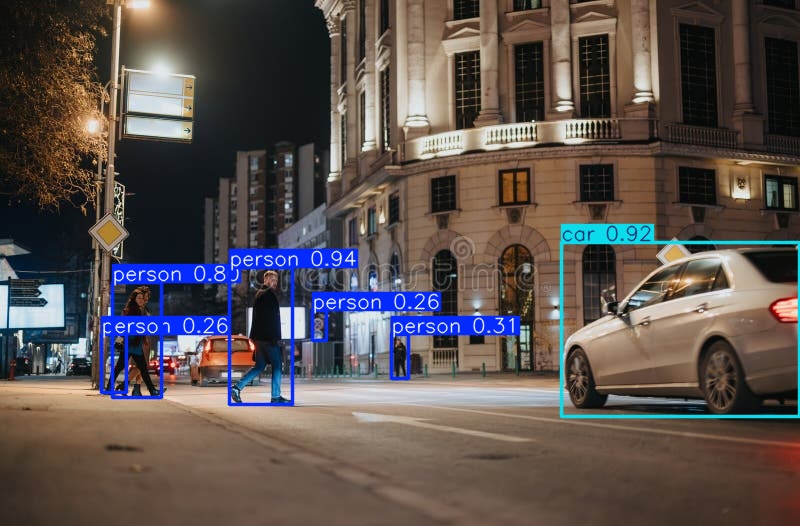

In [12]:
from IPython.display import Image, display

display(Image(filename="runs/detect/predict3/test.jpg"))